In [ ]:
# Local llm object
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="qwen3:8b",
    model_provider="ollama",
    num_ctx=2048,
)

In [1]:
# API llm object
from pathlib import Path
from dotenv import load_dotenv
import os

from langchain.chat_models import init_chat_model
env_path = Path(".env")
if not env_path.exists():
    raise FileNotFoundError(".env file not found")

load_dotenv()

gemini_llm = init_chat_model(
    model="gemini-3.1-flash-lite",
    api_key=os.getenv("GEMINI_API_KEY"),
    model_provider="google_genai",
    max_tokens=2048,
    temperature=0.7,
)

# Prompts & Chains

In [2]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [3]:
# Generation prompt
generation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a professional LinkedIn content assisitant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
        " Generate the best LinkedIn post possible for the user's request."
        " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [4]:
# Create Post generation chain
generation_chain = generation_prompt | gemini_llm

In [5]:
# Reflection prompt
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        CRITICAL ROUTING INSTRUCTION:
        - If the LinkedIn post is already excellent, meets all criteria, and requires no further edits, your entire response must simply be the word: [APPROVED]
        - If the post still needs improvements, provide your detailed critique as requested above. Do NOT include [APPROVED] if it needs work.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [6]:
# Create Reflection chain
reflect_chain = reflection_prompt | gemini_llm

# Nodes

In [7]:
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph import MessagesState
from langgraph.graph import END

In [8]:
# Generation node
def generation_node(state: MessagesState) -> dict:
    message_history = state["messages"]

    generated_post = generation_chain.invoke({"messages": message_history})
    
    # Extract content safely
    content_text = ""
    if isinstance(generated_post.content, list):
        # Extracts text if Gemini wraps it in a block list structure
        content_text = "".join([block.get("text", "") for block in generated_post.content if isinstance(block, dict)])
    else:
        content_text = str(generated_post.content)
        
    # Absolute Fallback
    if not content_text.strip():
        content_text = "Failed to revise draft. Retrying baseline structure."
        
    return {"messages": [AIMessage(content=content_text)]}

In [9]:
# Reflection node
def reflection_node(state: MessagesState) -> dict:
    message_history = state["messages"]

    reflection = reflect_chain.invoke({"messages": message_history})
    
    # Extract content safely
    reflection_text = ""
    if isinstance(reflection.content, list):
        reflection_text = "".join([block.get("text", "") for block in reflection.content if isinstance(block, dict)])
    else:
        reflection_text = str(reflection.content)
        
    # Absolute Fallback
    if not reflection_text.strip():
        reflection_text = "The draft looks good. [APPROVED]"
        
    return {"messages": [HumanMessage(content=reflection_text)]}

In [10]:
# Router node
def should_continue(state: MessagesState):
    messages = state["messages"]
    last_draft = messages[-1].content
    
    print(f"Current Message Count: {len(messages)}")
    print(f"Latest Draft Preview: {last_draft[:50]}...")
    print("----------------------------------------------------------------------")

    # Safety Check
    if len(messages) > 6:
        print("Safety limit hit. Exiting graph with current draft.")
        return "exit_graph"  # Maps to END
        
    # Quality Check: If the last message from the critique node (2 steps ago) -> [APPROVED]
    if len(messages) > 2:
        last_critique = messages[-2].content
        if "[APPROVED]" in last_critique:
            print("Draft approved by critic! Exiting graph.")
            return "exit_graph" # 👈 Maps to END

    # Else, keep the loop going and send it to the critic
    return "Reflect"  # Maps to "Reflect" node

# Workflow

In [11]:
# Initialize state graph
    # captures dynamic state
from langgraph.graph import StateGraph
graph = StateGraph(MessagesState)

### Add Nodes

In [12]:
graph.add_node("Generate", generation_node)

In [13]:
graph.add_node("Reflect", reflection_node)

### Add Edges

In [14]:
graph.add_edge("Reflect", "Generate")

In [15]:
graph.add_conditional_edges("Generate", should_continue,
    {   # Tells router what the return value of should_continue maps to
        "Reflect": "Reflect",
        "exit_graph": END,
    },
)

### Entry point & Compile

In [16]:
graph.set_entry_point("Generate")

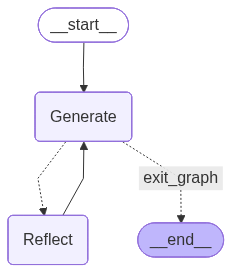

In [17]:
workflow = graph.compile()
workflow

In [18]:
print(workflow.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	Generate(Generate)
	Reflect(Reflect)
	__end__([<p>__end__</p>]):::last
	Generate -.-> Reflect;
	Generate -. &nbsp;exit_graph&nbsp; .-> __end__;
	Reflect --> Generate;
	__start__ --> Generate;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



# RUN

In [19]:
query = HumanMessage(content="""
        Write a linkedin post on creating a LinkedIn post agent.
    """
)

In [20]:
# Run agent
inputs = {"messages": [query]}
response = workflow.invoke(inputs)  # All responses

Current Message Count: 2
Latest Draft Preview: To make this post perform well, I have structured ...
----------------------------------------------------------------------
Current Message Count: 4
Latest Draft Preview: That’s great to hear! Since you’re ready to post, ...
----------------------------------------------------------------------
Draft approved by critic! Exiting graph.


In [21]:
from IPython.display import display, Markdown
display(Markdown(response["messages"][1].content))

To make this post perform well, I have structured it to follow the "Hook-Value-CTA" framework that works best on LinkedIn.

***

**Headline: I built an AI agent to write my LinkedIn posts. Here is what I learned.**

Most people think AI content is "soulless." 

I used to think the same. Then, I realized the problem wasn't the AI—it was the prompt. 

I spent the last week building a custom LinkedIn Agent to help me scale my content without losing my "voice." 

Here is the simple framework I used to move from generic AI output to high-performing posts:

**1. The "Persona" Injection**
Don’t just ask ChatGPT to "write a post." Feed it your past 5 best-performing posts. Tell the agent: *"Analyze these for tone, sentence structure, and vocabulary. Adopt this persona for all future drafts."*

**2. The Content Engine**
Instead of asking for a topic, I feed the agent raw data:
*   A messy voice note of a thought I had in the shower.
*   A bulleted list of a lesson I learned this week.
*   A link to an article I disagree with.
The agent’s only job is to organize that raw, authentic input into a structured narrative.

**3. The "Human-in-the-Loop" Polish**
This is where the magic happens. The agent drafts, but I do the "Final 10%." I add the personal anecdote, the controversial take, or the specific metric that only I have access to. 

**The result?**
I’ve cut my content creation time by 70%, but my engagement has actually *increased*. 

Why? Because I’m no longer staring at a blank page. I’m spending my energy on refining ideas rather than fighting with the cursor.

**The biggest takeaway:**
AI isn't here to replace your voice. It’s here to act as your editor, researcher, and structural engineer. 

If you treat it like an intern rather than a ghostwriter, you’ll start seeing results.

**Are you using AI to help with your content strategy, or are you still doing it all manually? Let’s discuss in the comments. 👇**

#ArtificialIntelligence #ContentStrategy #LinkedInGrowth #Automation #PersonalBranding

***

### 💡 Tips for your post:
*   **The Image:** Posts with a screenshot of your agent’s interface (or a simple diagram of your workflow) perform 2x better than text-only posts.
*   **The First Comment:** Once you post, be the first person to comment. You can add a link to a tool you used or a question to spark debate.
*   **Engagement:** If someone comments, reply with a question to keep the conversation going. LinkedIn's algorithm loves back-and-forth dialogue.

**Would you like me to adjust the tone? (e.g., make it more technical, more casual, or more "thought-leader" style?)**